In [ ]:
import glob
from multiprocessing import Pool
import time
import os
def match_table(file1,file2,target):
    start = time.time()
    os.system("java -jar jystilts.jar var_crossmatch.py "+file1+" "+file2+" "+target)
    end = time.time()
    print('Task runs %0.2f seconds.'%(end - start))

In [ ]:
file1='./extra_catalogues/standstar_pho.csv'
file2='./total_catalogues/w1_new_var_para_table4.csv'
target='./total_catalogues/new_var_tables/w1_new_std_pho_match_table4.csv'

In [ ]:
match_table(file1, file2,target)

In [ ]:
from multiprocessing import Pool

file1='./extra_catalogues/standstar_pho.csv'
thread_pool = Pool()
for i in range(4,18):
    file2='./total_catalogues/w1_new_var_para_table%d.csv'%i
    target='./total_catalogues/new_var_tables/w1_new_std_pho_match_table%d.csv'%i
    # match_table(file1,file2,target)
    thread_pool.apply_async(match_table,args=(file1,file2,target))
    print('task%d finished'%i)

thread_pool.close()
thread_pool.join()

In [3]:
import pandas as pd
table = pd.read_csv('./total_catalogues/w1_new_var_para_table1.csv')
print(len(table))

30651661


In [45]:
print(len(table))

30651661


In [24]:
stripe_table = table[table['dec']<3]
stripe_table = stripe_table[stripe_table['dec']>-3]
stripe_table = stripe_table[stripe_table['Mean']<16.5]
print(len(stripe_table))
# stripe_table = stripe_table.sample(410000)

512562


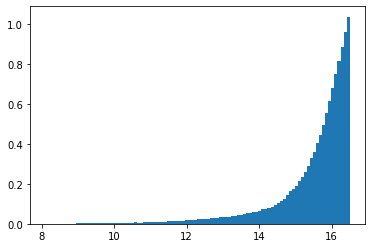

In [25]:
import matplotlib.pyplot as plt
import numpy as np
plt.hist(stripe_table['Mean'],bins=100,density=True)
plt.show()

In [26]:
tables = []
for i in (0,1,2,3,15,16,17):
    tables.append(pd.read_csv('./total_catalogues/new_var_tables/w1_new_std_pho_match_table%d.csv'%i))
table_std_pho = pd.concat(tables)
table_std_pho = table_std_pho[table_std_pho['Mean']<16.5]
len(table_std_pho)

414002

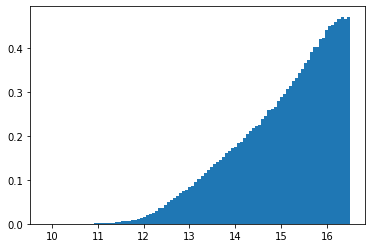

In [28]:
plt.hist(table_std_pho['Mean'],bins=100,density=True)
plt.show()

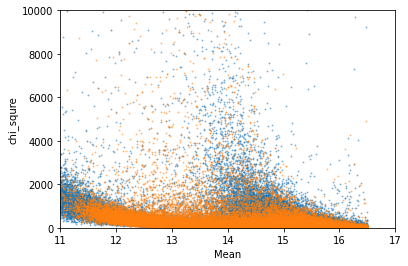

In [30]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(stripe_table['Mean'],stripe_table['chi_squre'],s=1,alpha=0.5,marker='*')
plt.scatter(table_std_pho['Mean'],table_std_pho['chi_squre'],s=1,alpha=0.5,marker='*')
plt.ylim(0,1e4)
plt.xlim(11,17)
plt.xlabel('Mean')
plt.ylabel('chi_squre')
plt.show()

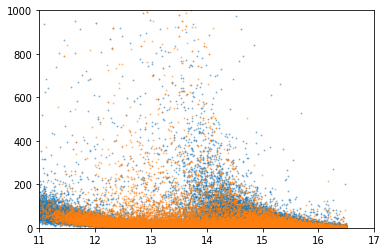

In [31]:
plt.scatter(stripe_table['Mean'],stripe_table['rcs'],s=1,alpha=0.5,marker='*')
plt.scatter(table_std_pho['Mean'],table_std_pho['rcs'],s=1,alpha=0.5,marker='*')
plt.ylim(0,1e3)
plt.xlim(11,17)
plt.show()

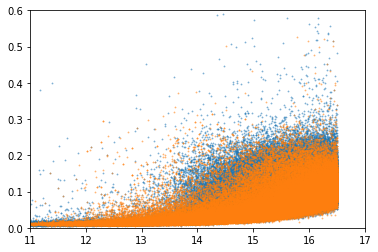

In [32]:
plt.scatter(stripe_table['Mean'],stripe_table['w_sigma'],s=1,alpha=0.5,marker='*')
plt.scatter(table_std_pho['Mean'],table_std_pho['w_sigma'],s=1,alpha=0.5,marker='*')
plt.ylim(0,0.6)
plt.xlim(11,17)
plt.show()

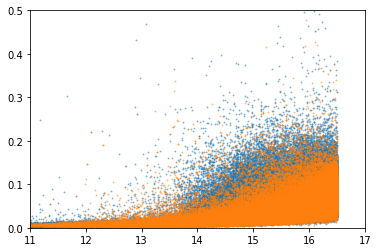

In [44]:

plt.scatter(stripe_table['Mean'],stripe_table['MAD'],s=1,alpha=0.5,marker='*')
plt.scatter(table_std_pho['Mean'],table_std_pho['MAD'],s=1,alpha=0.5,marker='*')
plt.ylim(0,0.5)
plt.xlim(11,17)
plt.show()

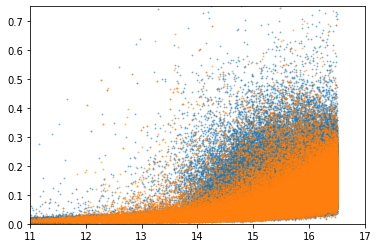

In [36]:
plt.scatter(stripe_table['Mean'],stripe_table['IQR'],s=1,alpha=0.5,marker='*')
plt.scatter(table_std_pho['Mean'],table_std_pho['IQR'],s=1,alpha=0.5,marker='*')
plt.ylim(0,0.75)
plt.xlim(11,17)

plt.show()

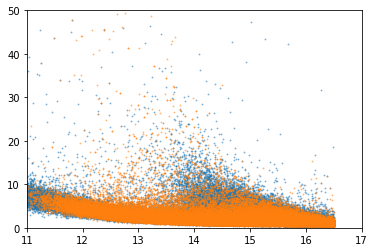

In [37]:
plt.scatter(stripe_table['Mean'],stripe_table['RmStat'],s=1,alpha=0.5,marker='*')
plt.scatter(table_std_pho['Mean'],table_std_pho['RmStat'],s=1,alpha=0.5,marker='*')
plt.ylim(0,50)
plt.xlim(11,17)

plt.show()

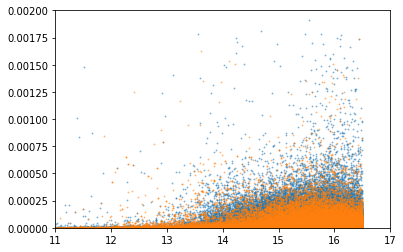

In [38]:
plt.scatter(stripe_table['Mean'],stripe_table['Nev'],s=1,alpha=0.5,marker='*')
plt.scatter(table_std_pho['Mean'],table_std_pho['Nev'],s=1,alpha=0.5,marker='*')
plt.ylim(0,0.002)
plt.xlim(11,17)
plt.show()

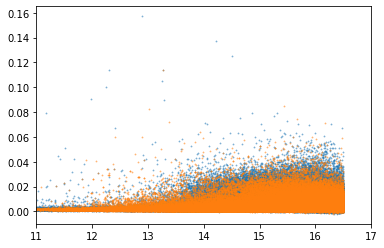

In [39]:
plt.scatter(stripe_table['Mean'],stripe_table['p2pv'],s=1,alpha=0.5,marker='*')
plt.scatter(table_std_pho['Mean'],table_std_pho['p2pv'],s=1,alpha=0.5,marker='*')
# plt.ylim(0,0.002)
plt.xlim(11,17)

plt.show()

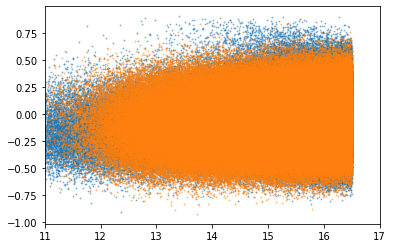

In [40]:
plt.scatter(stripe_table['Mean'],stripe_table['L1_acr'],s=1,alpha=0.5,marker='*')
plt.scatter(table_std_pho['Mean'],table_std_pho['L1_acr'],s=1,alpha=0.5,marker='*')
# plt.ylim(0,0.002)
plt.xlim(11,17)

plt.show()

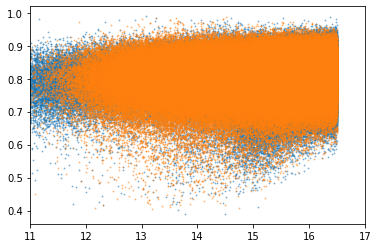

In [41]:
plt.scatter(stripe_table['Mean'],stripe_table['Stetson_K'],s=1,alpha=0.5,marker='*')
plt.scatter(table_std_pho['Mean'],table_std_pho['Stetson_K'],s=1,alpha=0.5,marker='*')
# plt.ylim(0,0.002)
plt.xlim(11,17)

plt.show()

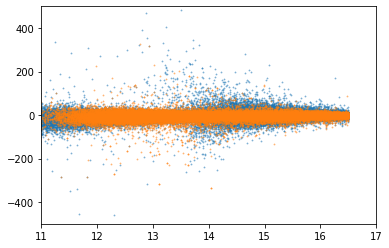

In [42]:
plt.scatter(stripe_table['Mean'],stripe_table['Stetson_J'],s=1,alpha=0.5,marker='*')
plt.scatter(table_std_pho['Mean'],table_std_pho['Stetson_J'],s=1,alpha=0.5,marker='*')
plt.ylim(-500,500)
plt.xlim(11,17)

plt.show()

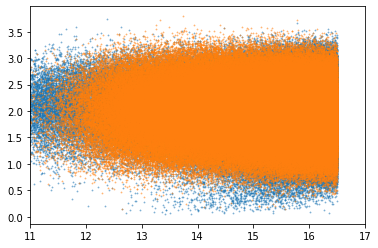

In [43]:
plt.scatter(stripe_table['Mean'],stripe_table['yita'],s=1,alpha=0.5,marker='*')
plt.scatter(table_std_pho['Mean'],table_std_pho['yita'],s=1,alpha=0.5,marker='*')
# plt.ylim(-500,500)
plt.xlim(11,17)

plt.show()

In [47]:
X = np.array(stripe_table[['Mean',
       'chi_squre', 'rcs', 'w_sigma', 'MAD', 'IQR', 'RmStat', 'Nev', 'p2pv',
       'L1_acr', 'Stetson_J', 'Stetson_K', 'yita']])
print(X)

[[14.53912705 39.85703095  1.2995351  ... -4.27361789  0.78827033
   2.22029132]
 [16.32462126 19.95686737  0.12911701 ... -2.35747601  0.79575438
   1.93146387]
 [16.31493459 41.41408732  1.23905609 ... -1.88092977  0.77779236
   1.97899768]
 ...
 [16.00542139 18.41031377  0.12630559 ...  2.58262697  0.68993704
   1.37206563]
 [16.39096046 17.92569799  0.06481125 ... -3.58432999  0.89539145
   2.48116258]
 [16.49425225 16.07985579 -0.1400722  ...  4.20317593  0.73768425
   1.32847025]]


In [48]:
from sklearn.manifold import TSNE
X_embedded = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(X)

In [51]:
print(X_embedded)

[[-13.755571 -56.6798  ]
 [-59.674572  22.0866  ]
 [-51.296883  53.851875]
 ...
 [-19.336878 -46.63288 ]
 [-51.058094  33.211517]
 [ 65.78434  -54.078663]]


(array([[   0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           18.,   90.,   56.,  199.,  285.,  239.,  185.,  166.,  166.,
          112.,   50.,   31.,    0.,    0.,    0.,    0.,    0.,    0.,
            0.,    0.,    0.],
        [   0.,    0.,    0.,    0.,    0.,    0.,    0.,   27.,  147.,
          241.,  299.,  354.,  363.,  388.,  368.,  384.,  392.,  308.,
          270.,  303.,  188.,  120.,   13.,    0.,    0.,    0.,    0.,
            0.,    0.,    0.],
        [   0.,    0.,    0.,    0.,    0.,    0.,   92.,  175.,  299.,
          283.,  406.,  503.,  571.,  499.,  557.,  579.,  532.,  463.,
          480.,  502.,  373.,  280.,  247.,   67.,    0.,    0.,    0.,
            0.,    0.,    0.],
        [   0.,    0.,    0.,    0.,   21.,  114.,  304.,  386.,  451.,
          526.,  477.,  626.,  658.,  661.,  650.,  660.,  648.,  663.,
          645.,  568.,  555.,  433.,  369.,  269.,   93.,   12.,    0.,
            0.,    0.,    0.],
        [   

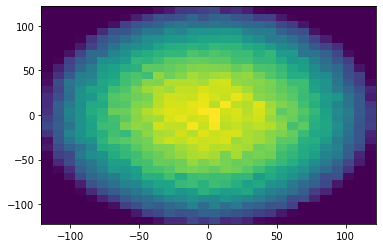

In [58]:
import matplotlib.pyplot as plt

plt.hist2d(X_embedded.T[0],X_embedded.T[1],bins=(30,30))

In [76]:
from sklearn import datasets, decomposition
pca = decomposition.PCA(n_components=3)
pca.fit(X)
X_transformed = pca.transform(X)

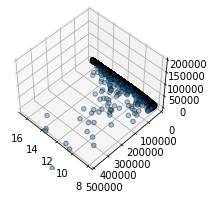

In [162]:
fig = plt.figure(1, figsize=(4, 3))
ax = fig.add_subplot(111, projection="3d", elev=48, azim=134)
ax.scatter(X[:, 0], X[:, 1], X[:, 2],  cmap=plt.cm.nipy_spectral, edgecolor="k")
# plt.xlim(8,14)
plt.ylim(0,0.5e6)
plt.show()

In [79]:
pca = decomposition.PCA(n_components=2)
pca.fit(X)
X_transformed = pca.transform(X)

In [81]:
print(len(X_transformed))

512562


(-100.0, 1000.0)

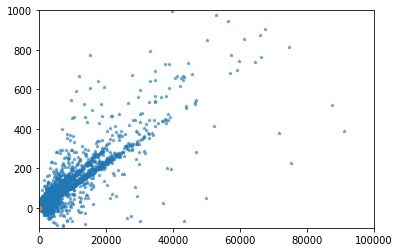

In [199]:
x,y = X_transformed[:,0],X_transformed[:,1]
plt.scatter(x,y,s=10,alpha=0.5,marker='*',)
plt.scatter(x[cluster0],y[cluster0],s=10,alpha=0.5,marker='*',)
plt.xlim(0,0.1e6)
plt.ylim(-1e2,1e3)

In [190]:
import itertools

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy import linalg

from sklearn import mixture

dpgmm = mixture.BayesianGaussianMixture(
    n_components=2,
    covariance_type="full",
    weight_concentration_prior=1e-2,
    weight_concentration_prior_type="dirichlet_process",
    mean_precision_prior=1e-2,
    covariance_prior=1e0 * np.eye(13),
    init_params="random",
    max_iter=100,
    random_state=2,
)

In [164]:
X.shape

(512562, 13)

In [165]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled1 = scaler.fit_transform(X)


/home/kangzihan/.local/lib/python3.10/site-packages/sklearn/mixture/_base.py:286: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


BayesianGaussianMixture(covariance_prior=array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]]),
                        init_params='random', mean_precision_prior=0.01,
                        n_components=4, random_state=2,
                        weight_concentration_prior=0.01)

In [191]:
dpgmm.fit(X_scaled1)

BayesianGaussianMixture(covariance_prior=array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]]),
                        init_params='random', mean_precision_prior=0.01,
                        n_components=2, random_state=2,
                        weight_concentration_prior=0.01)

(array([459150.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,  53412.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

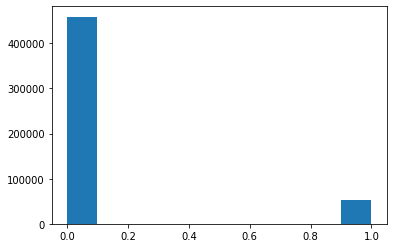

In [192]:
plt.hist(dpgmm.predict(X_scaled1))

In [193]:
X_predicted =dpgmm.predict(X_scaled1)
cluster0 = np.argwhere(X_predicted==0)
cluster1 = np.argwhere(X_predicted==1)
# cluster2 = np.argwhere(X_predicted==2)
# cluster3 = np.argwhere(X_predicted==3)

In [168]:
print(len(cluster0),len(cluster1),len(cluster2),len(cluster3))

9102 367751 56770 78939


['Mean',
       'chi_squre', 'rcs', 'w_sigma', 'MAD', 'IQR', 'RmStat', 'Nev', 'p2pv',
       'L1_acr', 'Stetson_J', 'Stetson_K', 'yita']

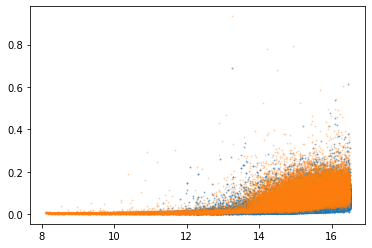

In [209]:

plt.scatter(table_std_pho['Mean'],table_std_pho['MAD'],s=1,alpha=0.5,marker='*')

plt.scatter(np.array(stripe_table['Mean'])[cluster1],
            np.array(stripe_table['MAD'])[cluster1],s=1,alpha=0.3,marker='*')
# plt.ylim(0,1e4)

plt.show()